In [1]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
# Import library to handle data
import pandas as pd

# Load dataset from CSV file
data = pd.read_csv("data.csv")

# Print dataset size (rows, columns)
print("Shape:", data.shape)

# Display first 5 rows to inspect data
print("\nFirst 5 rows:")
print(data.head())

# Separate features (X) and labels (y)
# Features = all gene columns (skip first 2 columns)
X = data.iloc[:, 2:]                 # your features (data)
feature_names = X.columns

# Labels = 'type' column
y = data['type']

# Check how many samples in each class
print("\nClass distribution:")
print(y.value_counts())

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 1. LOAD DATA (Module 1: Dataset Selection)
# Your screenshot shows the file is named 'data.csv'
data = pd.read_csv('data.csv')

# 2. SEPARATE FEATURES AND LABELS
# Based on your screenshot: features start from column 2, labels are in 'type'
X = data.iloc[:, 2:]  # Features: skip first 2 columns [cite: 69]
y = data['type']      # Target: 'type' column (tumor vs. normal) [cite: 63]

# 3. SPLIT DATA
# We use 'stratify=y' to maintain class balance for clinical reliability[cite: 86, 106].
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. PREPROCESSING (Module 2)
# Standardizing prevents high-dimensional gene features from dominating the model[cite: 67, 154].
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. TRAIN BASELINE MODEL (Module 4)
# Logistic Regression with L2 regularization to prevent overfitting[cite: 72, 146].
model = LogisticRegression(max_iter=1000, penalty='l2')
model.fit(X_train, y_train)

# 6. EVALUATION (Module 7)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. STRATIFIED K-FOLD (better for small + imbalanced data)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_model_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   # 🔥 important for your "normal" class
)

cv_scores = cross_val_score(rf_model_balanced, X_train, y_train, cv=cv)

print("Stratified K-Fold Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

# 2. Train + Evaluate
rf_model_balanced.fit(X_train, y_train)

rf_pred_balanced = rf_model_balanced.predict(X_test)

print(f"\nBalanced RF Accuracy: {accuracy_score(y_test, rf_pred_balanced):.4f}")
print("\nBalanced RF Classification Report:\n", classification_report(y_test, rf_pred_balanced))

In [ ]:
rf_model_balanced.fit(X_train, y_train)
rf_pred_balanced = rf_model_balanced.predict(X_test)

In [ ]:
# =========================
# COMPLETE WORKING CODE
# =========================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# =========================
# STEP 1: UPLOAD YOUR CSV
# =========================
from google.colab import files
uploaded = files.upload()

# show uploaded filenames
print("Uploaded files:", list(uploaded.keys()))

# put your uploaded CSV name here
filename = list(uploaded.keys())[0]

# load dataset
data = pd.read_csv(filename)

# =========================
# STEP 2: CHECK COLUMNS
# =========================
print("\nDataset columns:")
print(data.columns)

# change this if your label column is not called 'type'
target_column = 'type'

# =========================
# STEP 3: PLOT AND SAVE FIGURE
# =========================
plt.figure(figsize=(10, 6))

sns.countplot(
    data=data,
    x=target_column,
    palette='viridis',
    order=data[target_column].value_counts().index
)

plt.title("Genomic Subtype Distribution (Biometric Classes)")
plt.ylabel("Number of Samples")
plt.xlabel("Class Type")
plt.xticks(rotation=45)

plt.savefig("fig1.pdf", bbox_inches="tight")
plt.savefig("fig1.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()
print("\nSaved files:")
print(os.listdir())

# download the PDF for Overleaf
files.download("fig1.pdf")

# =========================
# STEP 4: OPTIONAL METRICS
# =========================
# Only run this part if y_test and rf_pred_balanced already exist

try:
    cm_balanced = confusion_matrix(y_test, rf_pred_balanced)

    FP = cm_balanced.sum(axis=0) - np.diag(cm_balanced)
    FN = cm_balanced.sum(axis=1) - np.diag(cm_balanced)
    TP = np.diag(cm_balanced)
    TN = cm_balanced.sum() - (FP + FN + TP)

    far = FP.sum() / (FP.sum() + TN.sum())
    frr = FN.sum() / (FN.sum() + TP.sum())

    print("\n--- BIOMETRIC SECURITY CHECKPOINT METRICS ---")
    print(f"False Acceptance Rate (FAR): {far:.4f}")
    print(f"False Rejection Rate (FRR): {frr:.4f}")
    print(f"Equal Error Rate (EER): {(far + frr) / 2:.4f}")

except NameError:
    print("\nSkipping metrics because y_test or rf_pred_balanced is not defined yet.")

## Checkpoint 2: Advanced Model Implementation

In this section, we extend the baseline Random Forest model by introducing
a PCA-based dimensionality reduction followed by an SVM classifier to
handle the high-dimensional gene expression data more effectively.

In [1]:
import pandas as pd

df = pd.read_csv('/content/data.csv')

df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [2]:
# Separate features and labels

# Remove 'samples' (ID column) and 'type' (label column) from features
X = df.drop(['samples', 'type'], axis=1)

# Store the target labels (cancer subtype)
y = df['type']

# Print shapes to verify data dimensions
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (44, 54675)
y shape: (44,)


In [3]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # ensures reproducibility
    stratify=y          # keeps class distribution balanced
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (35, 54675)
X_test: (9, 54675)
y_train: (35,)
y_test: (9,)


In [7]:
# Reduce the number of gene features using PCA

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Handle missing values using training-data mean
imputer = SimpleImputer(strategy='mean')

X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

# PCA cannot use more components than number of training samples
pca = PCA(n_components=30)

# Learn PCA from training data and transform training data
X_train_pca = pca.fit_transform(X_train_clean)

# Apply same PCA transformation to test data
X_test_pca = pca.transform(X_test_clean)

# Check new shapes
print("X_train_pca:", X_train_pca.shape)
print("X_test_pca:", X_test_pca.shape)

# Check explained variance
print("Total explained variance:", pca.explained_variance_ratio_.sum())

X_train_pca: (35, 30)
X_test_pca: (9, 30)
Total explained variance: 0.9524140438039184


In [8]:
# Train SVM model on PCA-reduced data

from sklearn.svm import SVC

# Create SVM model
svm_model = SVC(kernel='rbf', probability=True)

# Train the model
svm_model.fit(X_train_pca, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test_pca)

# Check that it worked
print("SVM training complete")
print("Number of predictions:", len(svm_pred))
print("First 5 predictions:", svm_pred[:5])

SVM training complete
Number of predictions: 9
First 5 predictions: ['basal' 'basal' 'basal' 'basal' 'basal']


In [10]:
# Evaluate SVM model performance

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Compute overall accuracy of the model
accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", accuracy)

# Print detailed classification metrics (precision, recall, f1-score)
print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred, zero_division=0))

# Display confusion matrix to see correct vs incorrect predictions
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, svm_pred))

SVM Accuracy: 0.8888888888888888

Classification Report:

              precision    recall  f1-score   support

         HER       0.00      0.00      0.00         1
       basal       0.89      1.00      0.94         8

    accuracy                           0.89         9
   macro avg       0.44      0.50      0.47         9
weighted avg       0.79      0.89      0.84         9


Confusion Matrix:

[[0 1]
 [0 8]]


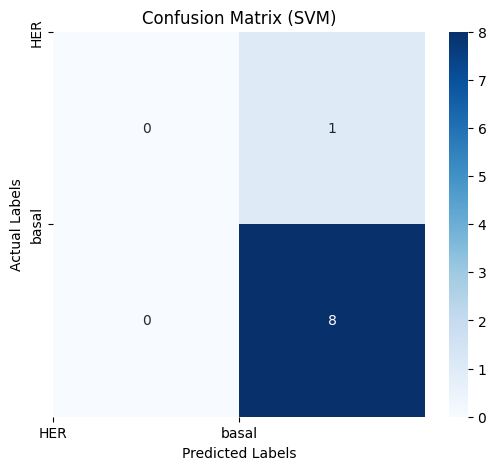

In [11]:
# Create confusion matrix to analyze model performance

# Import required libraries
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute confusion matrix using true labels and predicted labels
cm = confusion_matrix(y_test, svm_pred)

# Step 2: Plot the confusion matrix as a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Step 3: Add labels, title, and class names for better understanding
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

# Optional: Add class labels (VERY IMPORTANT for clarity)
plt.xticks(ticks=[0,1], labels=["HER", "basal"])
plt.yticks(ticks=[0,1], labels=["HER", "basal"])

# Step 4: Display the plot
plt.show()

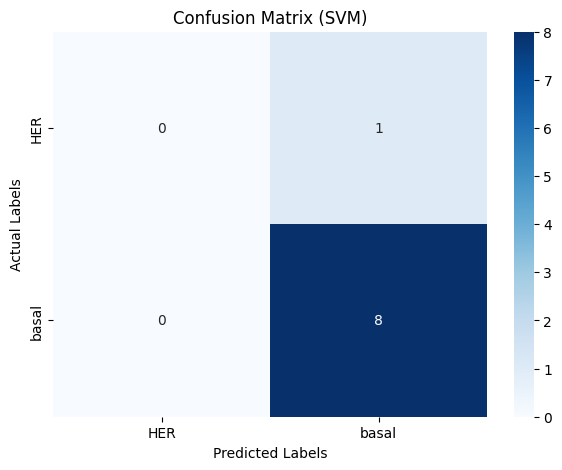

In [13]:
# Confusion Matrix with Class Names (easier to understand results)

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get unique class labels
labels = np.unique(y_test)

# Step 2: Create confusion matrix
cm = confusion_matrix(y_test, svm_pred, labels=labels)

# Step 3: Plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

# Step 4: Labels
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

# ✅ SAVE IMAGE (IMPORTANT)
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

# Step 5: Show plot
plt.show()

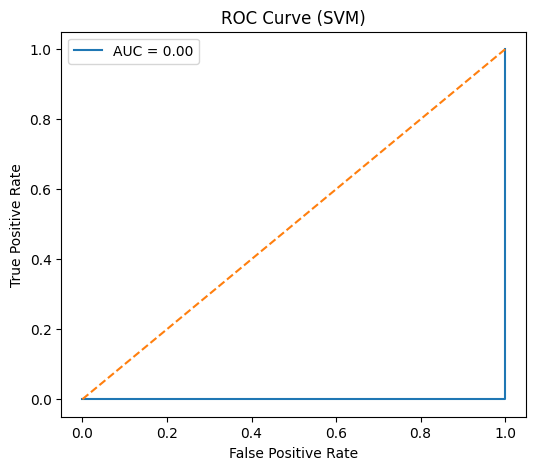

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary (HER = 1, basal = 0)
y_test_binary = (y_test == "HER").astype(int)

# Get probability scores
y_scores = svm_model.predict_proba(X_test_pca)[:, 1]

# Compute ROC
fpr, tpr, _ = roc_curve(y_test_binary, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM)")
plt.legend()

# Save image
plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')

plt.show()

Checkpoint 2 Results (SVM + PCA):

The confusion matrix shows that the SVM model correctly classifies all of the basal samples, but it fails to identify the HER class. Although the overall accuracy is 88.9%, this value is misleading because the dataset is imbalanced, with most samples belonging to the basal class. As a result, the model predicts all samples as basal, which leads to zero recall for the HER class. This indicates that the model is biased toward the majority class and does not perform well on minority classes.

The ROC curve also reflects this problem. The AUC score is very low (close to 0), which means the model is not able to distinguish between the HER and basal classes. This happens because the model only predicts one class and does not learn a meaningful decision boundary for the minority class.

Using PCA helped reduce the dimensionality of the gene expression data from over 54,000 features to 30 principal components while still preserving about 95% of the total variance. This made the model more efficient and helped reduce the risk of overfitting. However, the results show that further improvements, such as class balancing or tuning the model parameters, are needed to improve performance on less represented cancer subtypes.